In [21]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.optim import Adam

In [22]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

class ReluNet(nn.Module):
    def __init__(self):
        super(ReluNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)
    
class GeluNet(nn.Module):
    def __init__(self):
        super(GeluNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.gelu(self.fc1(x))
        x = F.gelu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)
    
class GluNet(nn.Module):
    def __init__(self):
        super(GluNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 64 * 2)
        self.fc2 = nn.Linear(64, 32 * 2)
        self.fc3 = nn.Linear(32, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.glu(self.fc1(x))
        x = F.glu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    'ReluNet': ReluNet(),
    'GeluNet': GeluNet(),
    'GluNet': GluNet()
}
optimizers = {
    name: Adam(model.parameters(), lr=0.00001)
    for name, model in models.items()
}


criterion = nn.CrossEntropyLoss()
num_epochs = 40
train_losses = {name: [] for name in models.keys()}
test_accuracies = {name: [] for name in models.keys()}

for name, model in models.items():
    optimizer = optimizers[name]
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        train_losses[name].append(avg_loss)
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        accuracy = 100 * correct / total
        test_accuracies[name].append(accuracy)
        print(f'{name} - Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%')

ReluNet - Epoch [1/40], Loss: 2.2847, Test Accuracy: 19.87%
ReluNet - Epoch [2/40], Loss: 2.2336, Test Accuracy: 35.64%
ReluNet - Epoch [3/40], Loss: 2.1791, Test Accuracy: 43.69%
ReluNet - Epoch [4/40], Loss: 2.1209, Test Accuracy: 46.91%
ReluNet - Epoch [5/40], Loss: 2.0580, Test Accuracy: 52.25%
ReluNet - Epoch [6/40], Loss: 1.9904, Test Accuracy: 56.47%
ReluNet - Epoch [7/40], Loss: 1.9196, Test Accuracy: 60.67%
ReluNet - Epoch [8/40], Loss: 1.8480, Test Accuracy: 64.35%
ReluNet - Epoch [9/40], Loss: 1.7756, Test Accuracy: 67.00%
ReluNet - Epoch [10/40], Loss: 1.7034, Test Accuracy: 68.53%
ReluNet - Epoch [11/40], Loss: 1.6318, Test Accuracy: 70.91%
ReluNet - Epoch [12/40], Loss: 1.5613, Test Accuracy: 72.99%
ReluNet - Epoch [13/40], Loss: 1.4933, Test Accuracy: 74.22%
ReluNet - Epoch [14/40], Loss: 1.4281, Test Accuracy: 75.50%
ReluNet - Epoch [15/40], Loss: 1.3656, Test Accuracy: 76.47%
ReluNet - Epoch [16/40], Loss: 1.3061, Test Accuracy: 77.22%
ReluNet - Epoch [17/40], Loss: 1.

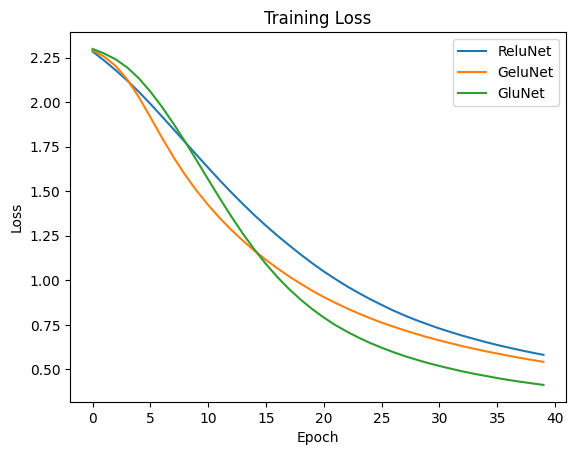

In [23]:
for name in models.keys():
    plt.plot(train_losses[name], label=name)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
models = {
    'ReluNet': ReluNet(),
    'GeluNet': GeluNet(),
    'GluNet': GluNet()
}
optimizers = {
    'ReluNet': Adam(ReluNet().parameters(), lr=0.001),
    'GeluNet': Adam(GeluNet().parameters(), lr=0.001),
    'GluNet': Adam(GluNet().parameters(), lr=0.001)
}

